In [1]:
import os
import sys
import gc
from pathlib import Path   
os.chdir('/zhome/71/c/146676/texture_tomography')
import h5py
import numpy as np

from package.texture_tomography.operators.pfo_and_projection_batched_opencl import PFO_OPENCL_BATCHED, estimate_L_power

import matplotlib.pyplot as plt
from multiprocessing import Pool
import yaml


from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_huber_opencl import FISTAHuberOpenCL
from package.texture_tomography.gpu_live_tracker import GPUMemoryLogger
from package.texture_tomography.operators.operator_memory_model import OperatorMemoryModel
from package.texture_tomography.operators.memory_tracker import MemoryCounter
from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_memory_model import FISTAMemoryModel
from package.texture_tomography.material import Material
import pyopencl.array as clarray

from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

from package.texture_tomography.operators.create_pfo_matrix import pfmatrix_sparseeval_gpu,sparse_pf_innerprod_gpu,interp_theta_4d_gpu, interp_theta_3d_gpu, build_pfsparse_program, sum_over_x_gpu, clip_nonnegative_gpu
from package.texture_tomography.multiresolution_refiner import OrientationTree, OrientationNode, generate_hopf_grid_fzone, invert_grid

import pyopencl as cl
from scipy.spatial.transform import Rotation as ROT

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
config_path = "configs/bb_config_1.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

grid_resolution_parameter = cfg['grid_resolution_parameter']
kernel_sigma = cfg['kernel_sigma']
N_theta = cfg['N_theta']
N_chi = cfg['N_chi']
N_rot = cfg['N_rot']
Nx = cfg['Nx']
Ny = cfg['Ny']
peak_width = cfg['peak_width']
datapath = cfg["datapath"]
absorption_file = cfg['absorption_file']
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
cor_offset = cfg["cor_offset"]
N_seg = N_theta*N_chi
filename = cfg['integrated_file']
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']


In [3]:
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
N_mat = len(filenames)

materials = []

for i_mat in range(N_mat):
    path = cif_folder / filenames[i_mat]
    material = Material.from_cif(
        cif_path=path,
        wavelength_kev=wavelength_kev,
        min_two_theta=min_two_theta,
        max_two_theta=max_two_theta,
        intensity_cutoff_fraction=reflection_cutoff,
    )
    materials.append(material)



In [4]:
grid_resolution_parameter = 6      # example
kernel_sigma = 0.25                # example
sigma_levels = [kernel_sigma]      # start with single level

grids = []

for mat in materials:
    tree = OrientationTree.from_hopf_fzone(
        mat.point_group_matrices,
        grid_resolution_parameter=grid_resolution_parameter,
        sigma_levels=sigma_levels,
    )
    grids.append(tree)

In [5]:
with h5py.File(datapath + absorption_file, 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dtc= file['entry/instrument/xspress3']
    data_all_events = dtc['all_events'][:].reshape(181,362)
    data_output_count_rate = dtc['output_count_rate'][:].reshape(181,362)
    data_att = dtc['window_counts'][:][:,0].reshape(181,362)


print('Loaded shape:', data_att.shape)



N_workers = 16  # adjust to match available CPUs

# --- Get list of dataset keys (exclude metadata) ---
with h5py.File(filename, 'r') as f:
    keys = [k for k in f.keys() if k != 'two_theta']
keys = sorted(keys, key=lambda x: int(x))


# --- Worker function ---
def load_single(key):
    with h5py.File(filename, 'r') as f:
        arr = f[key][...]
    return arr

with h5py.File(filename, 'r') as f:
    two_theta = f['two_theta'][:]


# --- Parallel load ---
with Pool(processes=N_workers) as pool:
    data_list = pool.map(load_single, keys)

# --- Combine into single array ---
data = np.stack(data_list, axis=0)

print('Loaded shape:', data.shape)
data_corrected = data/data_att[:,:,None,None]*100

Loaded shape: (181, 362)
Loaded shape: (181, 362, 90, 120)


In [6]:
all_data_reshaped = data_corrected.reshape((N_rot, Nx, N_chi*N_theta))

In [7]:
op = PFO_OPENCL_BATCHED(
        cfg = cfg,
        materials=materials,
        grids=grids,
        two_thetas = two_theta,
        max_gb=1.0,
        verbose=False)

In [8]:
print(op.K_sum)
print(op.K_list)
print(op.K_sum*op.Nx*op.Ny*4/1e6)
print(op.K_sum*op.N_rot*op.Nx*4/1e6)
## todo: Implement varying ODF-resolution for different materials. Consider scaling... should the ODF scale accordingly? 

3476
[ 22 444 148 148 444  83 444 218 888  74 218 218  22  22  83]
402.65984
911.017888


In [ ]:
queue = op.queue
Nx, Ny, K = op.Nx, op.Ny, op.K_sum

x_gpu = clarray.zeros(
    queue,
    (Nx, Ny, K),
    dtype=np.float32,
    order="F",
)

out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(queue, out_cpu)
assert out_gpu.flags.c_contiguous
# l1 constant: 1e7
# tv constant: 2e-6
# L constant for l1: 5e11
norm_sq = estimate_L_power(op, niter=10, seed=0, eps=1e-30, verbose=1)
solver = FISTAOpenCL(op, prox_kind="nonneg", lam=1e2, L=1.1*norm_sq)


solver.run(x_gpu, out_gpu, niter=20, verbose=1, diagnostics_interval=1)


[power 01] L_est=1.297508e+07  ||z||=3.675407e+08


[power 02] L_est=1.857062e+11  ||z||=3.004889e+11
[power 03] L_est=6.315632e+11  ||z||=6.731539e+11
[power 04] L_est=7.905446e+11  ||z||=8.263757e+11
[power 05] L_est=9.368082e+11  ||z||=9.694408e+11
[power 06] L_est=1.057302e+12  ||z||=1.077069e+12
[iter    1/20] obj=1.901295e+06  f=1.901295e+06  g=0.000000e+00  ||x||=7.016325e-04  ||grad||=8.160208e+08  tau=8.598e-13  beta=0.000e+00
[iter    2/20] obj=1.597415e+06  f=1.597415e+06  g=0.000000e+00  ||x||=7.549938e-04  ||grad||=1.524207e+08  tau=8.598e-13  beta=2.818e-01
[iter    3/20] obj=1.578410e+06  f=1.578410e+06  g=0.000000e+00  ||x||=8.074199e-04  ||grad||=8.669855e+07  tau=8.598e-13  beta=4.340e-01
[iter    4/20] obj=1.569604e+06  f=1.569604e+06  g=0.000000e+00  ||x||=8.541144e-04  ||grad||=6.732654e+07  tau=8.598e-13  beta=5.311e-01
[iter    5/20] obj=1.563082e+06  f=1.563082e+06  g=0.000000e+00  ||x||=8.999860e-04  ||grad||=5.610642e+07  tau=8.598e-13  beta=5.988e-01
[iter    6/20] obj=1.557974e+06  f=1.557974e+06  g=0.000000e

AttributeError: 'NoneType' object has no attribute 'get'

In [10]:
coeffs = x_gpu.get().transpose((0,1,2))[::-1,::-1]
# op.free_memory()
# del x_sol_gpu
# del out_gpu
# del x0_gpu
# gc.collect()

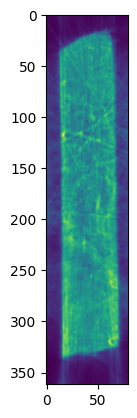

In [11]:
plt.imshow(coeffs.sum(axis=-1))

(362, 80, 3476)
[ 22 444 148 148 444  83 444 218 888  74 218 218  22  22  83]


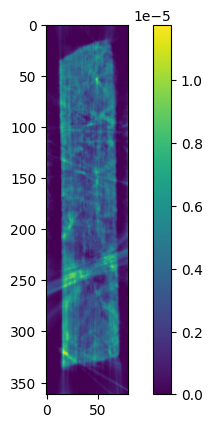

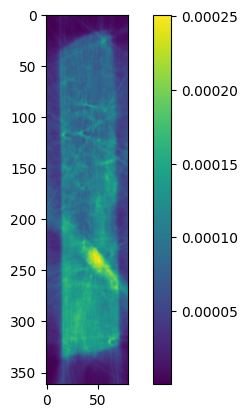

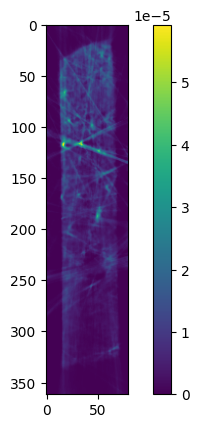

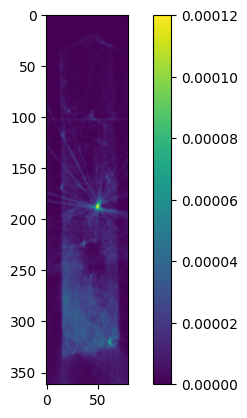

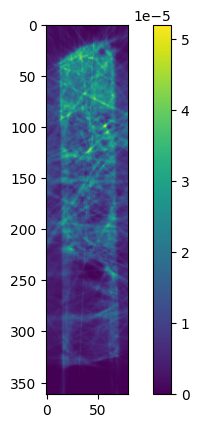

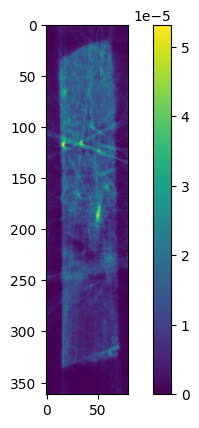

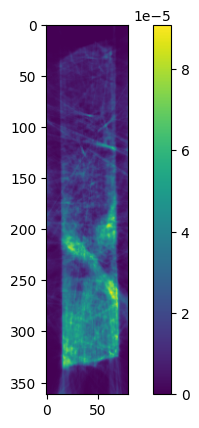

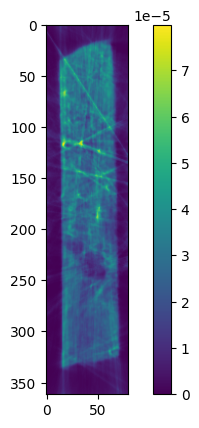

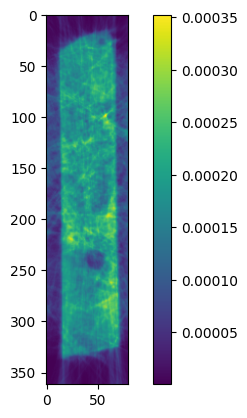

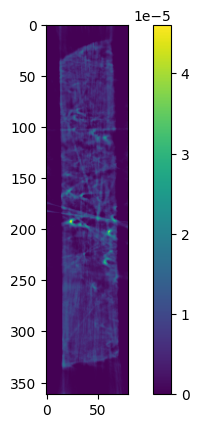

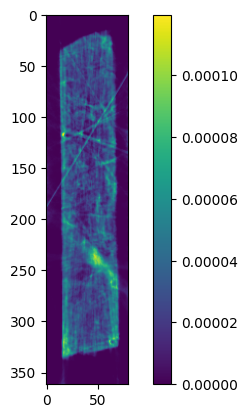

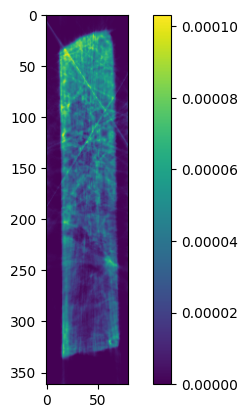

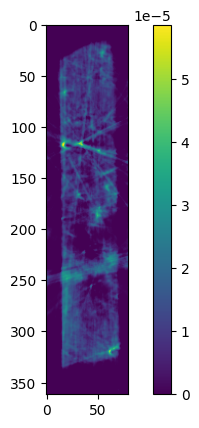

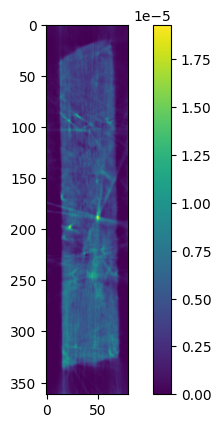

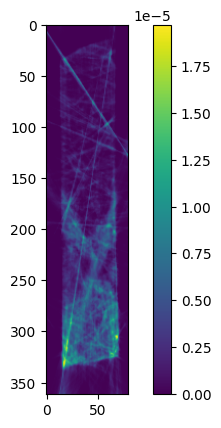

In [12]:
print(coeffs.shape)
print(op.K_list)
cumult_K_list = np.cumsum(np.concatenate([np.array([0]), np.array(op.K_list)]))
for i in range(op.N_mat):
    plt.imshow(coeffs[:,:,cumult_K_list[i]:cumult_K_list[i+1]].sum(axis=-1))
    plt.colorbar()
    plt.show()

In [13]:
print(cumult_K_list)

[   0   22  466  614  762 1206 1289 1733 1951 2839 2913 3131 3349 3371
 3393 3476]


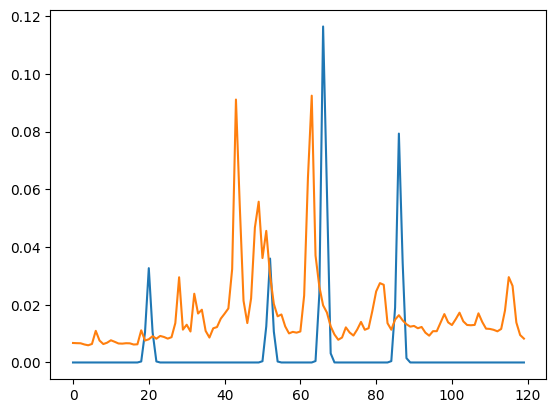

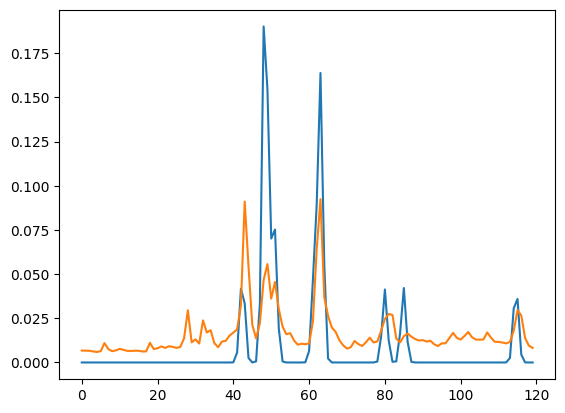

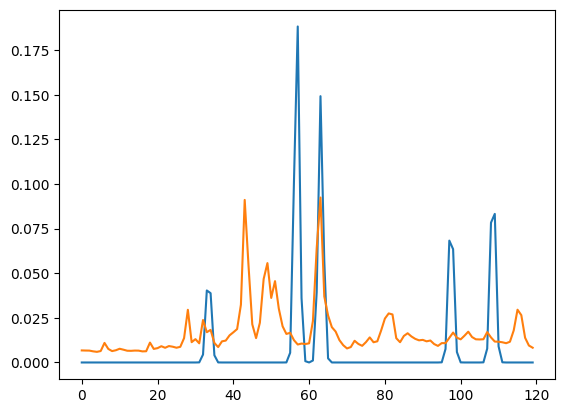

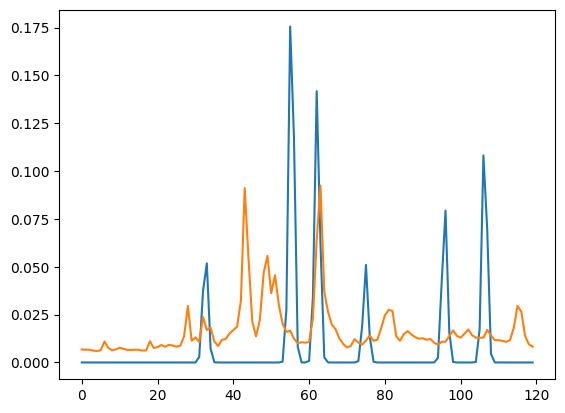

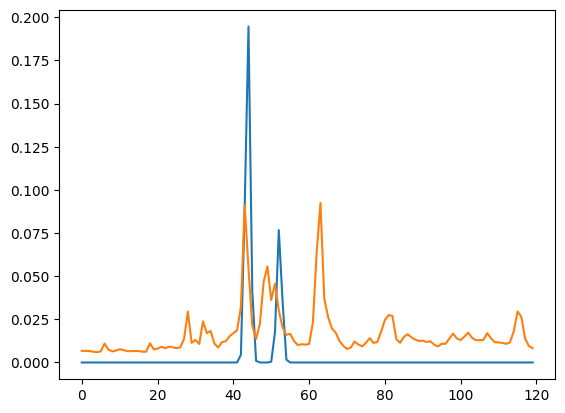

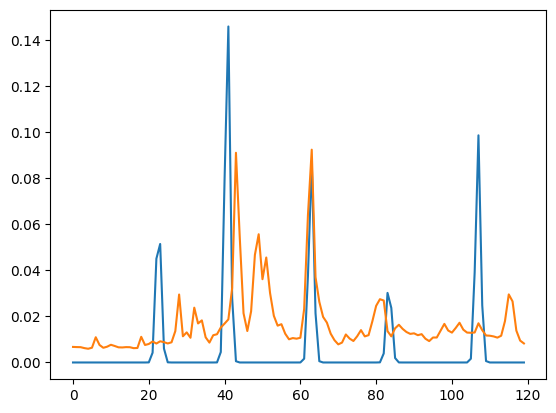

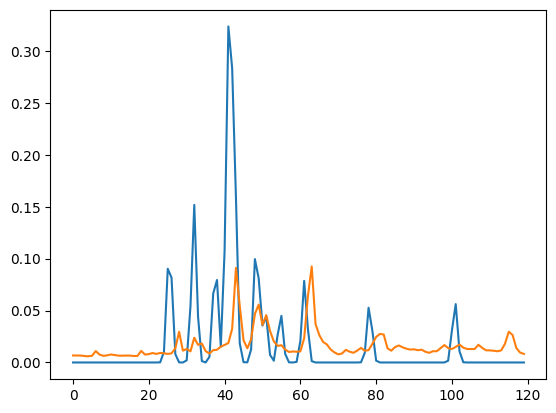

In [14]:


for i_basis in range(op.N_mat-8):

    arr_basis = clarray.zeros(
        queue,
        (Nx, Ny, K),
        dtype=np.float32,
        order="F"
    )
    arr_basis[:, :, cumult_K_list[i_basis]:cumult_K_list[i_basis+1]].fill(1.0)
    out_basis = clarray.empty(
        queue,
        (N_rot, Nx, N_seg),
        dtype=np.float32,
        order="C",
    )

    op.direct_cl(arr_basis, out_basis)
    out_cpu = out_basis.get().reshape((N_rot, Nx, N_chi, N_theta))

    y_basis1 = out_cpu.sum(axis=(0,1,2))
    y_data = data_corrected.sum(axis=(0,1,2))
    plt.plot(y_basis1/5e12)
    plt.plot(y_data/y_data.sum()*2)
    plt.show()

/zhome/71/c/146676/miniconda3/envs/cil/lib/python3.11/site-packages/pyopencl/__init__.py:570: CompilerWarning: From-source build succeeded, but resulted in non-empty logs:
Build on <pyopencl.Device 'NVIDIA A100-PCIE-40GB' on 'NVIDIA CUDA' at 0x563e82d24570> succeeded, but said:

(): Warning: Function pfmatrix_count_sparse is a kernel, so overriding noinline attribute. The function may be inlined when called.
(): Warning: Function pfmatrix_write_sparse is a kernel, so overriding noinline attribute. The function may be inlined when called.
(): Warning: Function sparse_pf_innerprod_4d is a kernel, so overriding noinline attribute. The function may be inlined when called.
(): Warning: Function interp_theta_4d is a kernel, so overriding noinline attribute. The function may be inlined when called.
(): Warning: Function interp_theta_3d is a kernel, so overriding noinline attribute. The function may be inlined when called.
(): Warning: Function sum_over_x is a kernel, so overriding noinline at

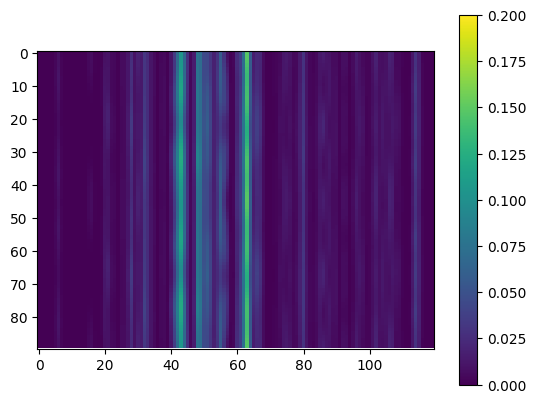

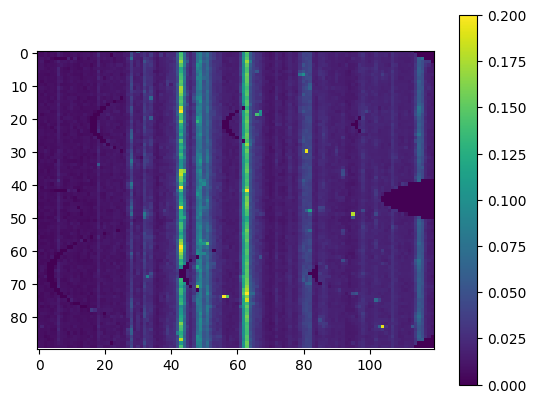

In [15]:
pf_prg = build_pfsparse_program(op.ctx)
kernel_pfmatrix_count_sparse = cl.Kernel(pf_prg, "pfmatrix_count_sparse")
kernel_pfmatrix_write_sparse = cl.Kernel(pf_prg, "pfmatrix_write_sparse")
kernel_sparse_pf_innerprod_4d = cl.Kernel(pf_prg, "sparse_pf_innerprod_4d")
kernel_interp3d = cl.Kernel(pf_prg, "interp_theta_3d")
kernel_interp4d = cl.Kernel(pf_prg, "interp_theta_4d")
kernel_sum_over_x = cl.Kernel(pf_prg, "sum_over_x")
kernel_clip_nonnegative = cl.Kernel(pf_prg, "clip_nonnegative")

prediction_gpu = op.direct(x_gpu)
prediction_cpu = prediction_gpu.get().reshape((N_rot, Nx, N_chi, N_theta))
res_gpu = out_gpu - prediction_gpu
clip_nonnegative_gpu(op.queue, kernel_clip_nonnegative, res_gpu)
res_gpu = res_gpu.reshape((N_rot, Nx, N_chi, N_theta))

plt.imshow(prediction_cpu[0,90])
plt.colorbar()
plt.clim([0,0.2])
plt.show()

plt.imshow(data_corrected[0,90])
plt.colorbar()
plt.clim([0,0.2])
plt.show()
